# Model-Free RL for Portfolio Allocation

Train PPO and A2C agents, evaluate with shared returns, and visualize RL convergence.

## Strategy
1. Load shared returns (for fair comparison with DP)
2. Train PPO and A2C on each scenario
3. Save results to `rl_results.pkl`
4. Visualize RL convergence: utility, wealth, and allocation trends

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

import importlib
import ppo
importlib.reload(ppo)
from ppo import PortfolioEnv, train_ppo, train_a2c
from utils import cara_utility, generate_shared_returns, hold_policy, heuristic_policy

plt.style.use('seaborn-v0_8-whitegrid')

# ============================================================
# Scenario Configurations (must match DP.ipynb)
# ============================================================
SCENARIOS = {
    'Base (n=3, T=5)': {
        'n': 3, 'T': 5, 'r': 0.03, 'A': 0.5,
        'a_k': [0.08, 0.06, 0.10],
        's_k': [0.02, 0.015, 0.04],
        'p_init': [0.25, 0.25, 0.25, 0.25],
    },
    'Two Assets (n=2, T=5)': {
        'n': 2, 'T': 5, 'r': 0.03, 'A': 0.7,
        'a_k': [0.09, 0.14],
        's_k': [0.02, 0.04],
        'p_init': [0.50, 0.25, 0.25],
    },
    'Four Assets (n=4, T=5)': {
        'n': 4, 'T': 5, 'r': 0.03, 'A': 0.5,
        'a_k': [0.08, 0.06, 0.10, 0.07],
        's_k': [0.02, 0.015, 0.04, 0.025],
        'p_init': [0.20, 0.20, 0.20, 0.20, 0.20],
    },
    'Four Assets Long (n=4, T=7)': {
        'n': 4, 'T': 7, 'r': 0.02, 'A': 0.7,
        'a_k': [0.06, 0.08, 0.10, 0.13],
        's_k': [0.015, 0.02, 0.025, 0.04],
        'p_init': [0.40, 0.15, 0.15, 0.15, 0.15],
    },
    'Long Horizon (n=3, T=9)': {
        'n': 3, 'T': 9, 'r': 0.03, 'A': 0.5,
        'a_k': [0.08, 0.06, 0.10],
        's_k': [0.02, 0.015, 0.04],
        'p_init': [0.25, 0.25, 0.25, 0.25],
    },
    'High Risk Aversion (A=3.0)': {
        'n': 3, 'T': 5, 'r': 0.03, 'A': 3.0,
        'a_k': [0.08, 0.10, 0.12],
        's_k': [0.02, 0.025, 0.03],
        'p_init': [0.50, 0.20, 0.15, 0.15],
    },
    'Low Risk Aversion (A=0.1)': {
        'n': 3, 'T': 5, 'r': 0.03, 'A': 0.1,
        'a_k': [0.08, 0.10, 0.12],
        's_k': [0.02, 0.025, 0.03],
        'p_init': [0.50, 0.20, 0.15, 0.15],
    },
}

NUM_EVAL = 2000
SEED = 42

print(f"Defined {len(SCENARIOS)} scenarios")

Defined 7 scenarios


## 1. Load Shared Returns

In [14]:
import os

# Load shared returns (from DP.ipynb or generate fresh)
shared_returns = {}
if os.path.exists('dp_results.pkl'):
    with open('dp_results.pkl', 'rb') as f:
        dp_saved = pickle.load(f)
    shared_returns = dp_saved['shared_returns']
    print(f"Loaded shared returns from dp_results.pkl for {len(shared_returns)} scenarios")
else:
    print("No dp_results.pkl found. Generating shared returns...")
    for name, cfg in SCENARIOS.items():
        shared_returns[name] = generate_shared_returns(
            NUM_EVAL, cfg['T'], cfg['n'], cfg['a_k'], cfg['s_k'], seed=SEED)
    print(f"Generated shared returns for {len(shared_returns)} scenarios")

Loaded shared returns from dp_results.pkl for 7 scenarios


## 2. Train RL Methods

In [15]:
def simulate_rl_model(model, cfg, shared_rets, num_episodes=NUM_EVAL):
    """Simulate a trained PPO/A2C model with shared returns.
    Records POST-rebalance allocation (from env.step info dict).
    """
    n, T, A = cfg['n'], cfg['T'], cfg['A']
    env = PortfolioEnv(**cfg)
    wealth_paths = np.zeros((num_episodes, T + 1))
    alloc_history = np.zeros((num_episodes, T, n + 1))
    terminal_wealths = np.zeros(num_episodes)

    for ep in range(num_episodes):
        obs, _ = env.reset()
        wealth_paths[ep, 0] = env.wealth
        for t in range(T):
            action, _ = model.predict(obs, deterministic=True)
            env._shared_return = shared_rets[ep, t].copy()
            obs, reward, done, _, info = env.step(action)
            rebal_cash = info['rebalanced_cash']
            rebal_risky = info['rebalanced_risky']
            alloc_history[ep, t] = np.concatenate([[rebal_cash], rebal_risky])
            wealth_paths[ep, t + 1] = env.wealth
        terminal_wealths[ep] = env.wealth

    utils = cara_utility(terminal_wealths, A)
    return {
        'avg_utility': float(np.mean(utils)),
        'std_err': float(np.std(utils) / np.sqrt(num_episodes)),
        'avg_wealth': float(np.mean(terminal_wealths)),
        'med_wealth': float(np.median(terminal_wealths)),
        'wealth_paths': wealth_paths,
        'terminal_wealths': terminal_wealths,
        'alloc_history': alloc_history,
    }

print("Helper functions defined.")

Helper functions defined.


In [ ]:
rl_results = {}

for scenario_name, cfg in SCENARIOS.items():
    sr = shared_returns[scenario_name]
    rl_cfg = {**cfg, 'leverage_factor': 2.0}
    results = {}

    print(f"\n{'#'*70}")
    print(f"  {scenario_name}")
    print(f"{'#'*70}")

    # --- PPO ---
    print("  [PPO] Training (500K steps, lr=1e-3)...")
    t0 = time.time()
    env_ppo = PortfolioEnv(**rl_cfg)
    model_ppo = train_ppo(env_ppo, timesteps=500_000, lr=0.001)
    results['PPO'] = simulate_rl_model(model_ppo, rl_cfg, sr)
    print(f"    utility={results['PPO']['avg_utility']:.5f} ({time.time()-t0:.1f}s)")

    # --- A2C ---
    print("  [A2C] Training (1M steps, n_steps=512, lr=5e-4)...")
    t0 = time.time()
    env_a2c = PortfolioEnv(**rl_cfg)
    model_a2c = train_a2c(env_a2c, timesteps=1_000_000, lr=0.0005, n_steps=512)
    results['A2C'] = simulate_rl_model(model_a2c, rl_cfg, sr)
    print(f"    utility={results['A2C']['avg_utility']:.5f} ({time.time()-t0:.1f}s)")

    rl_results[scenario_name] = results

print(f"\nDone! Trained RL for {len(rl_results)} scenarios.")

In [18]:
# Save RL results
with open('rl_results.pkl', 'wb') as f:
    pickle.dump({'results': rl_results, 'SCENARIOS': SCENARIOS,
                 'NUM_EVAL': NUM_EVAL, 'SEED': SEED}, f)
print(f"Saved RL results to rl_results.pkl")

Saved RL results to rl_results.pkl


## 3. Visualizations

In [19]:
colors = {
    'PPO': 'tab:orange', 'A2C': 'tab:red',
}
linestyles = {
    'PPO': '--', 'A2C': '--',
}
markers = {
    'PPO': 'D', 'A2C': 'v',
}

### Utility Over Time

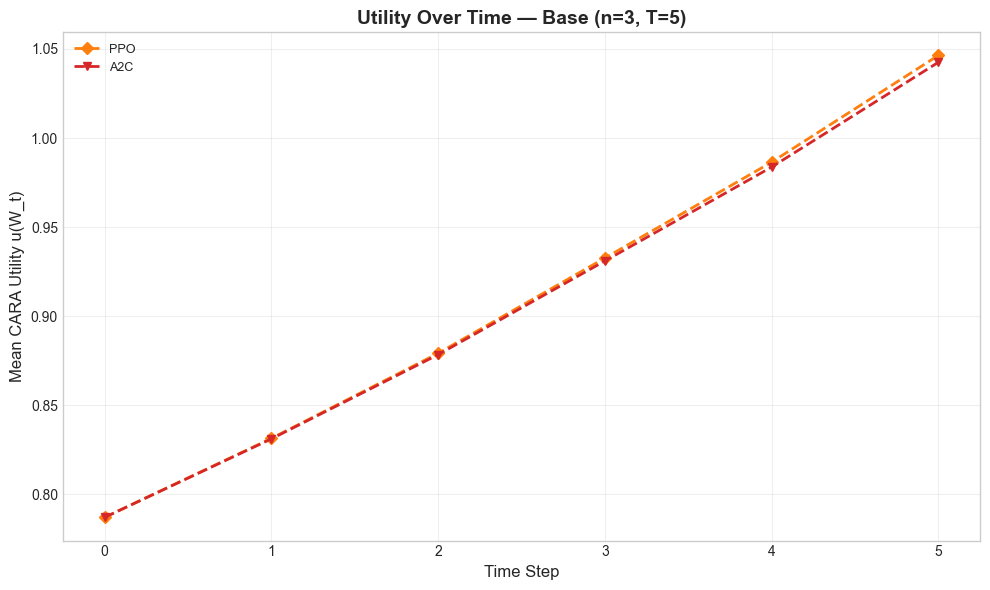

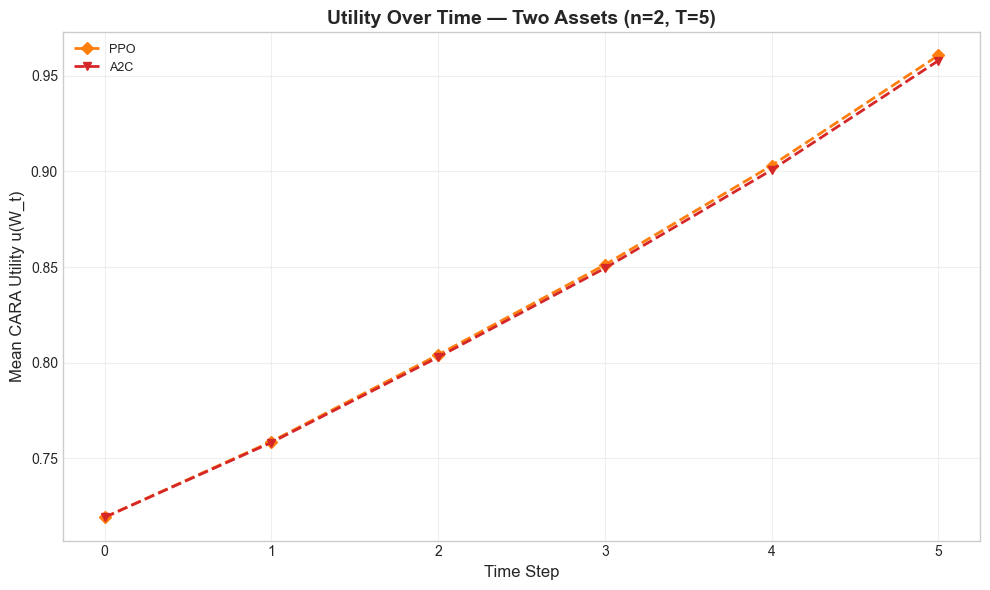

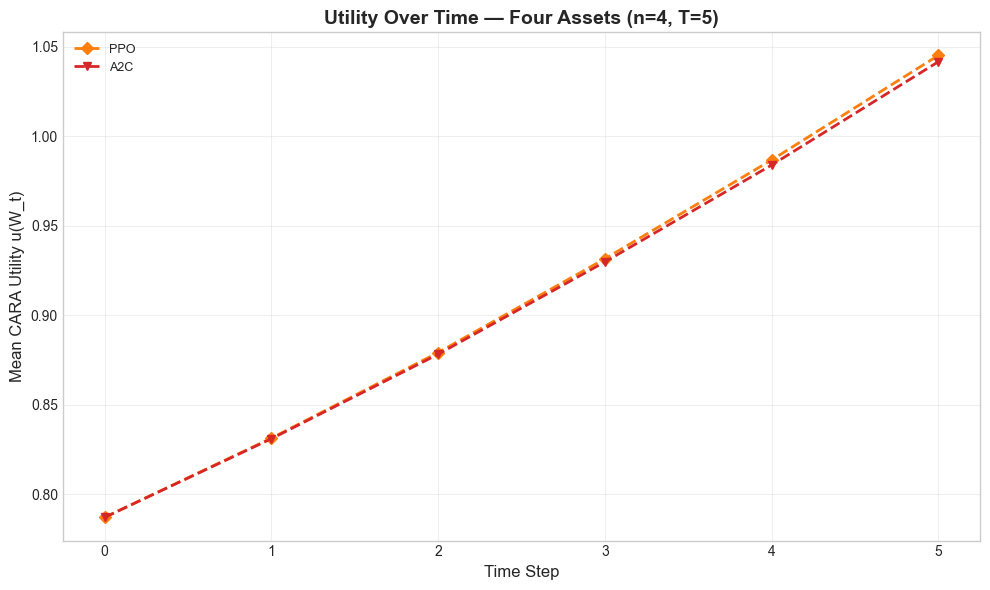

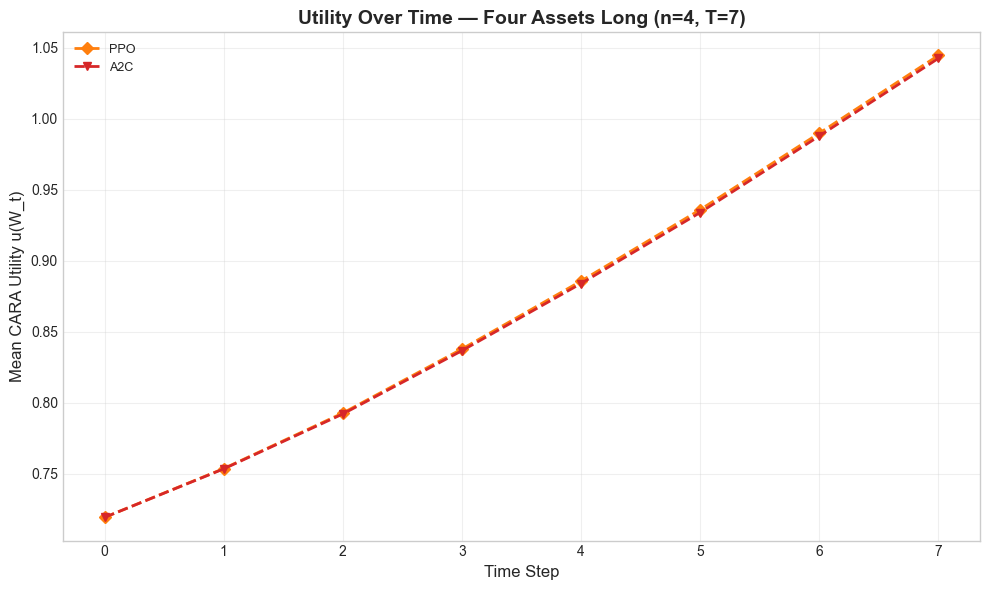

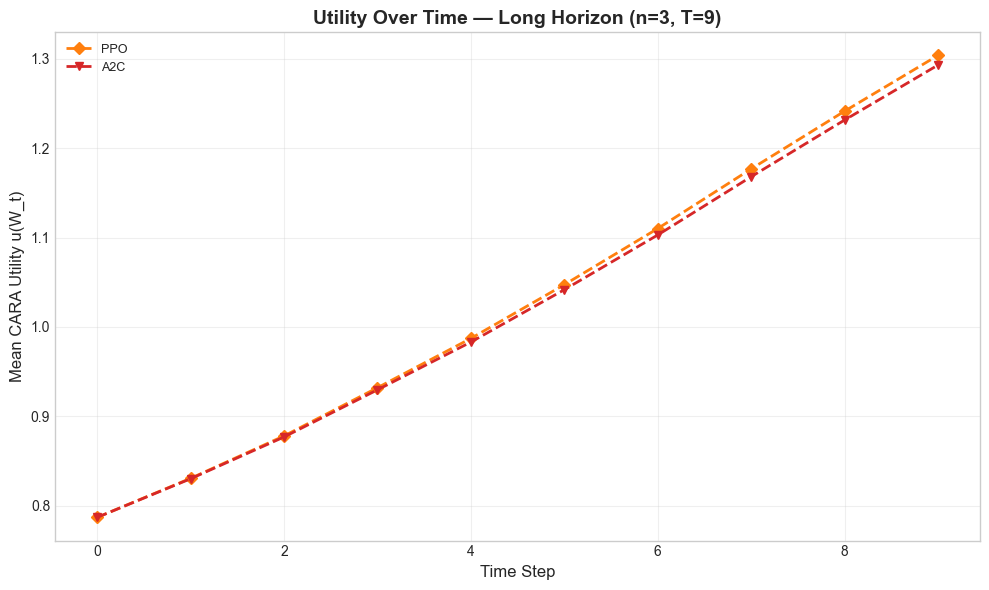

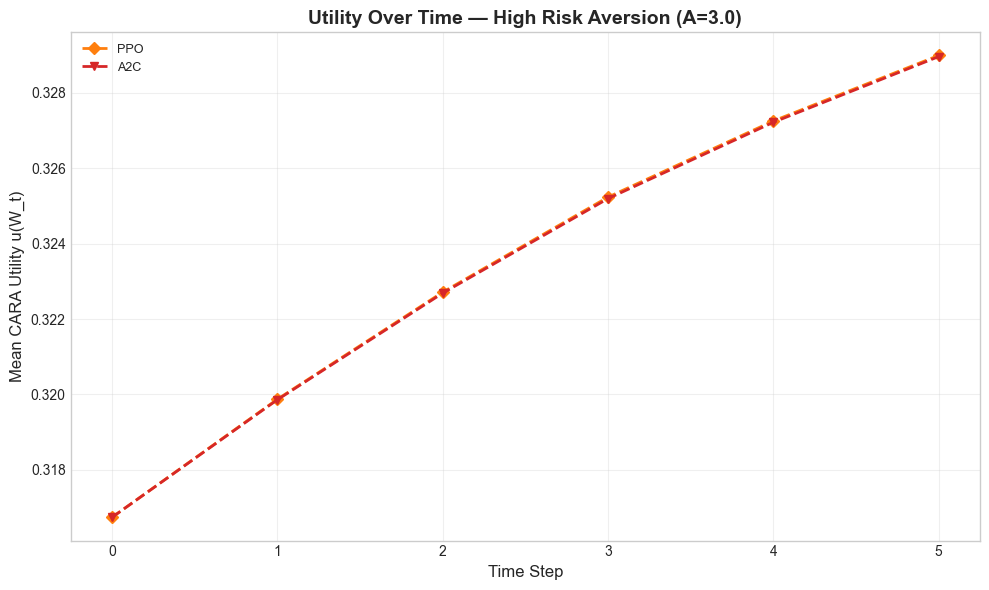

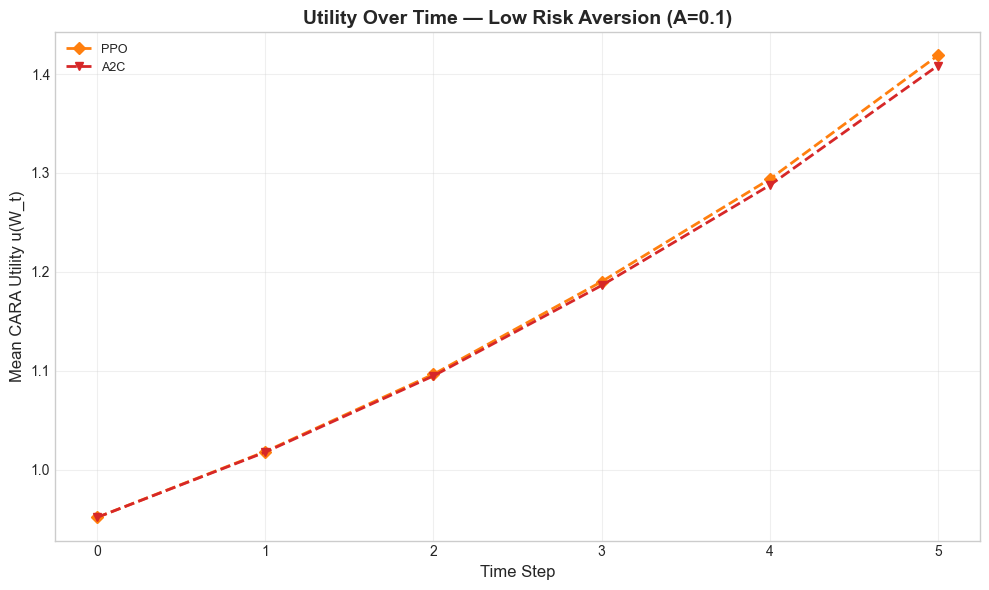

In [20]:
for scenario_name, results in rl_results.items():
    cfg = SCENARIOS[scenario_name]
    A = cfg['A']
    T = cfg['T']
    ts = np.arange(T + 1)

    fig, ax = plt.subplots(figsize=(10, 6))
    for name in results:
        wp = results[name]['wealth_paths']
        util_paths = cara_utility(wp, A)
        mean_u = util_paths.mean(axis=0)
        c = colors.get(name, 'black')
        ls = linestyles.get(name, '-')
        mk = markers.get(name, None)
        ax.plot(ts, mean_u, label=name, color=c, linestyle=ls,
                marker=mk, markersize=6, linewidth=2)
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel('Mean CARA Utility u(W_t)', fontsize=12)
    ax.set_title(f'Utility Over Time — {scenario_name}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Wealth Over Time

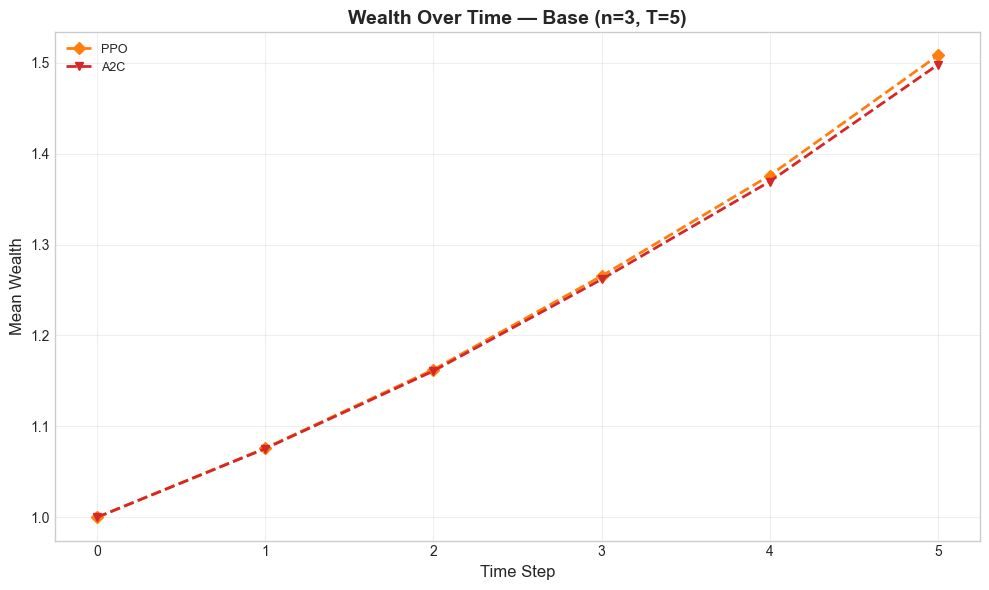

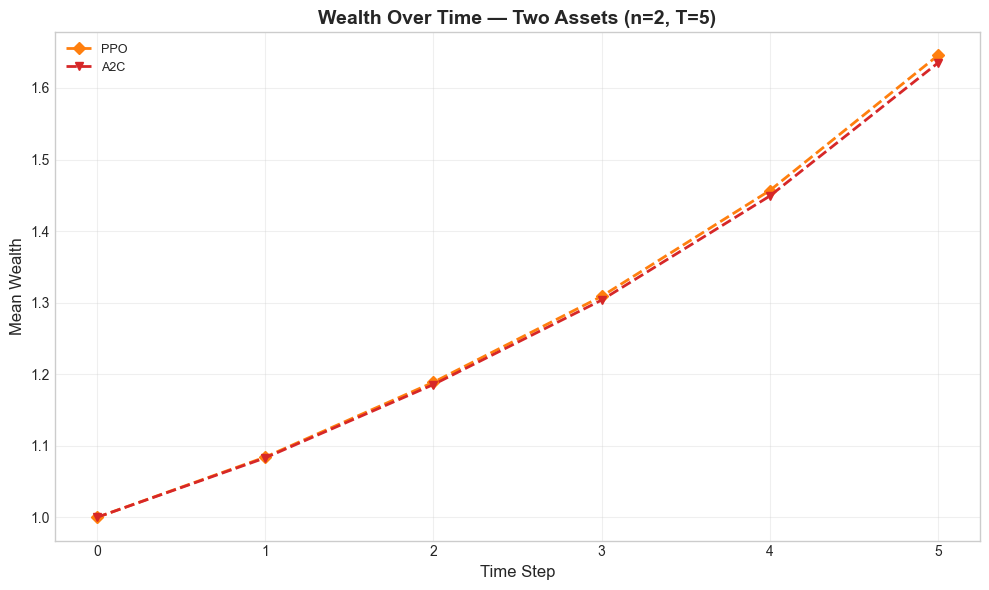

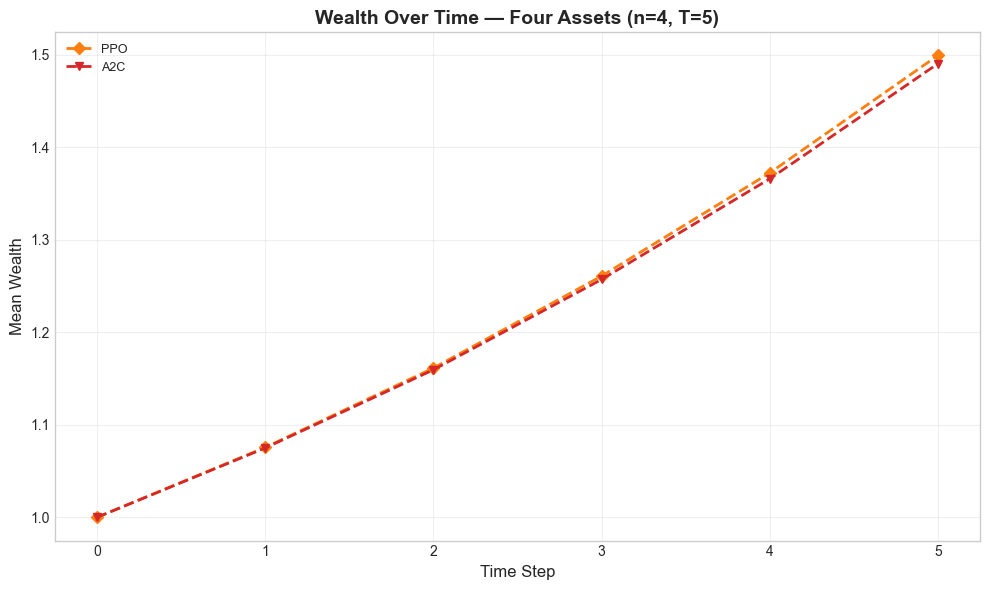

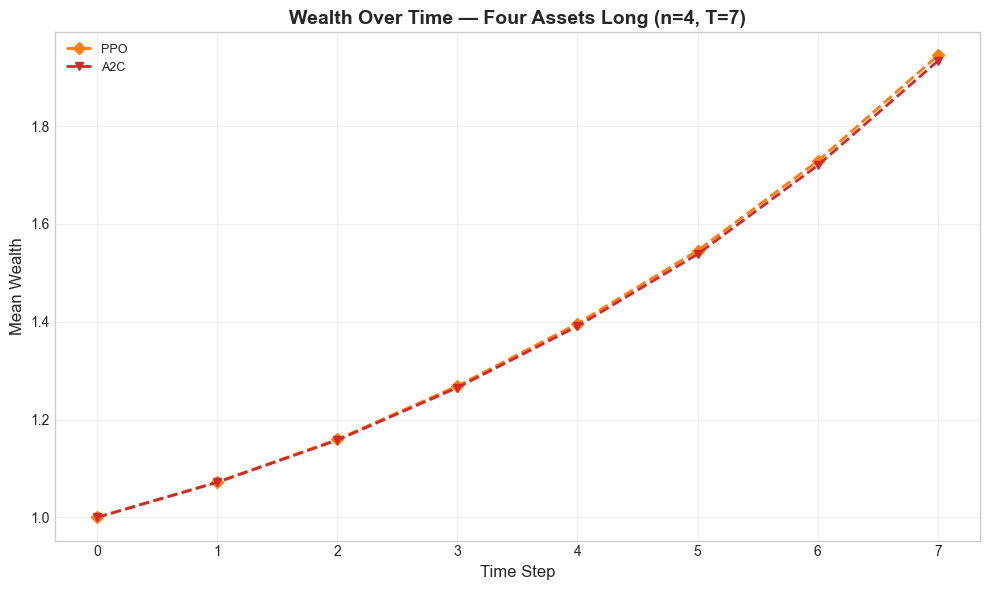

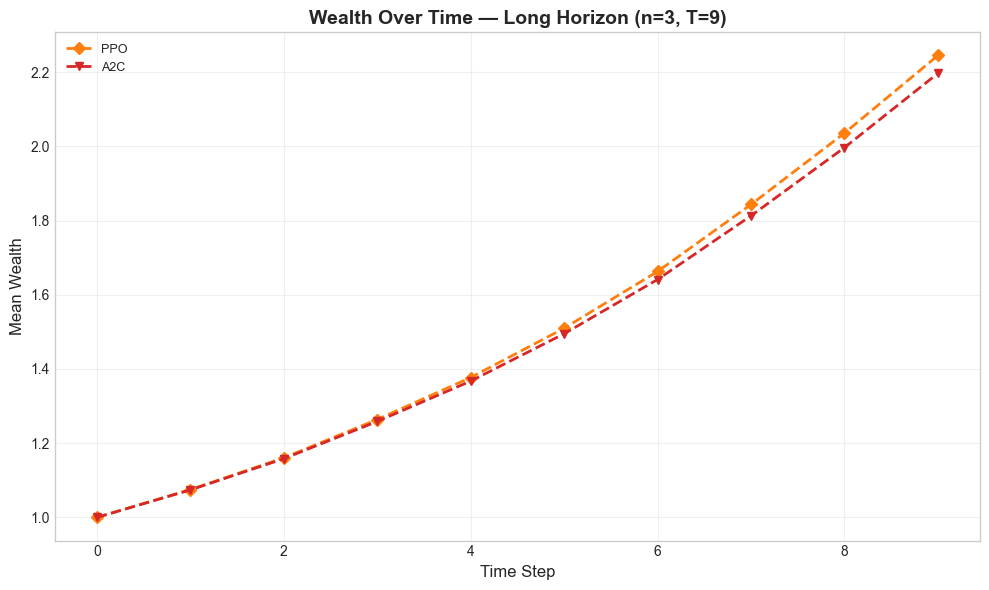

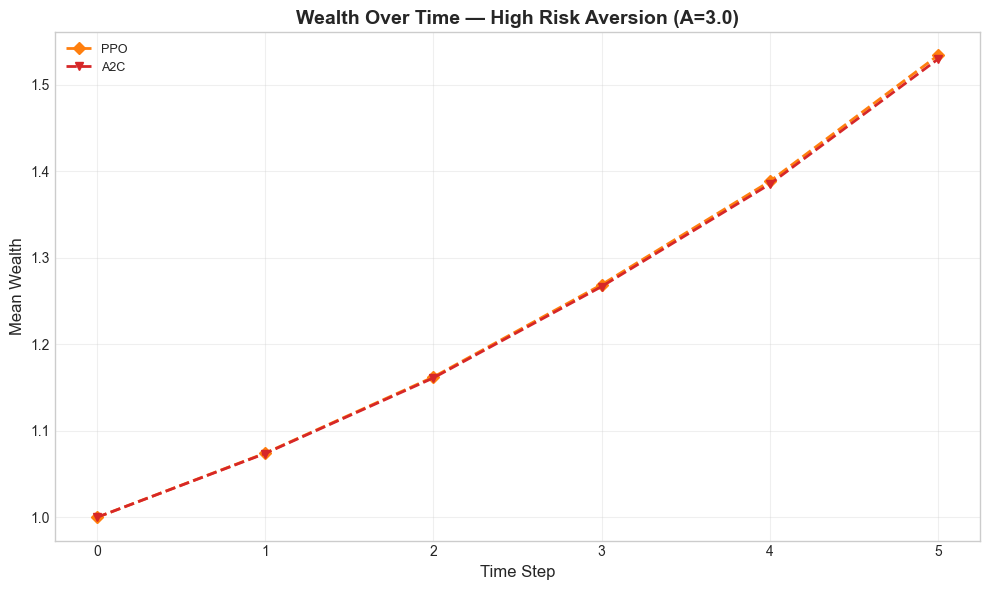

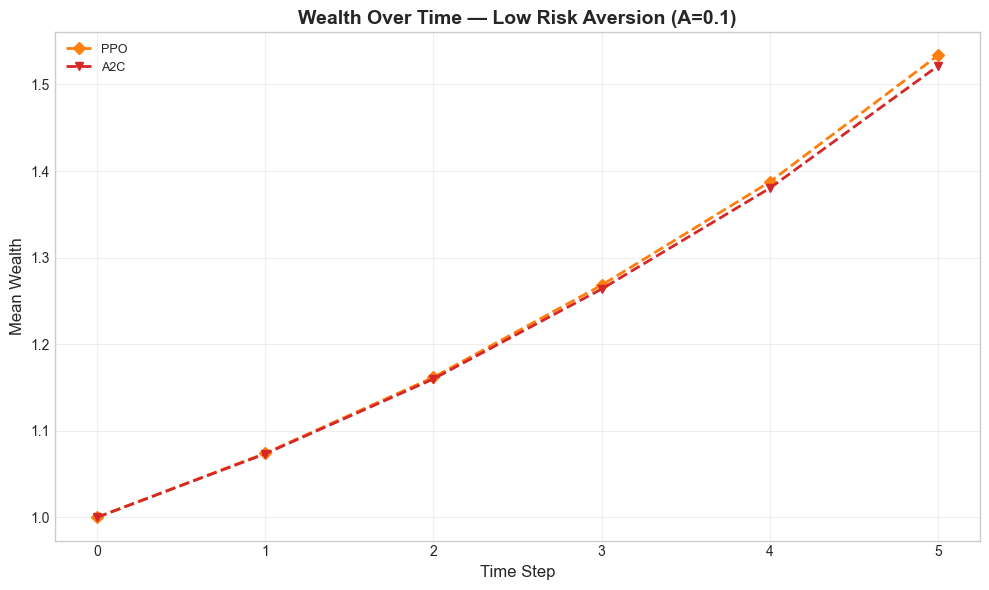

In [21]:
for scenario_name, results in rl_results.items():
    cfg = SCENARIOS[scenario_name]
    T = cfg['T']
    ts = np.arange(T + 1)

    fig, ax = plt.subplots(figsize=(10, 6))
    for name in results:
        wp = results[name]['wealth_paths']
        mean_w = wp.mean(axis=0)
        c = colors.get(name, 'black')
        ls = linestyles.get(name, '-')
        mk = markers.get(name, None)
        ax.plot(ts, mean_w, label=name, color=c, linestyle=ls,
                marker=mk, markersize=6, linewidth=2)
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel('Mean Wealth', fontsize=12)
    ax.set_title(f'Wealth Over Time — {scenario_name}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Allocation Trends

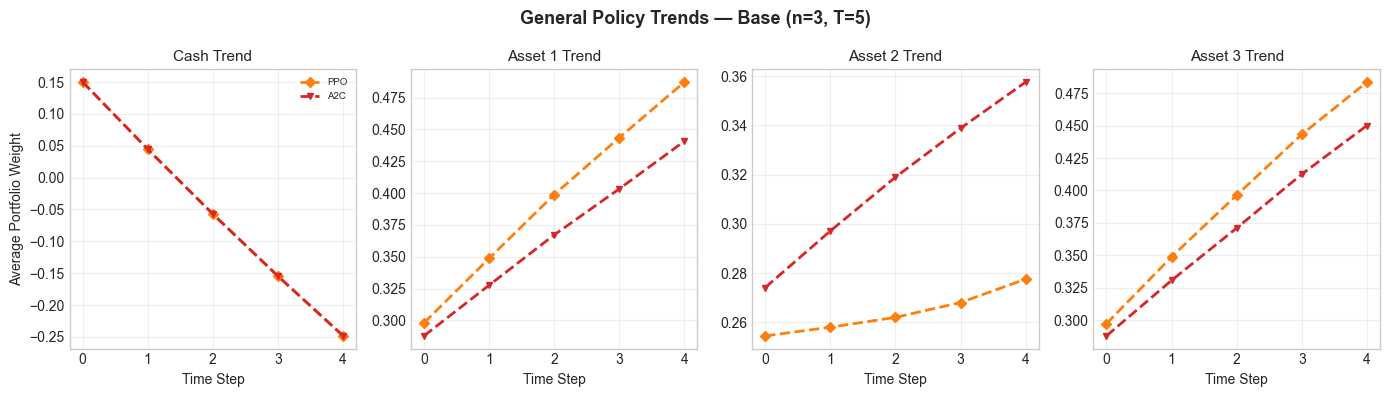

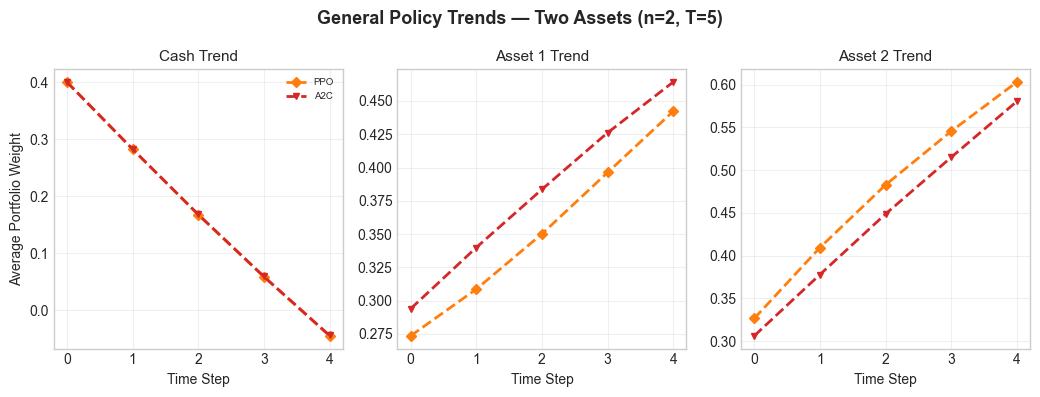

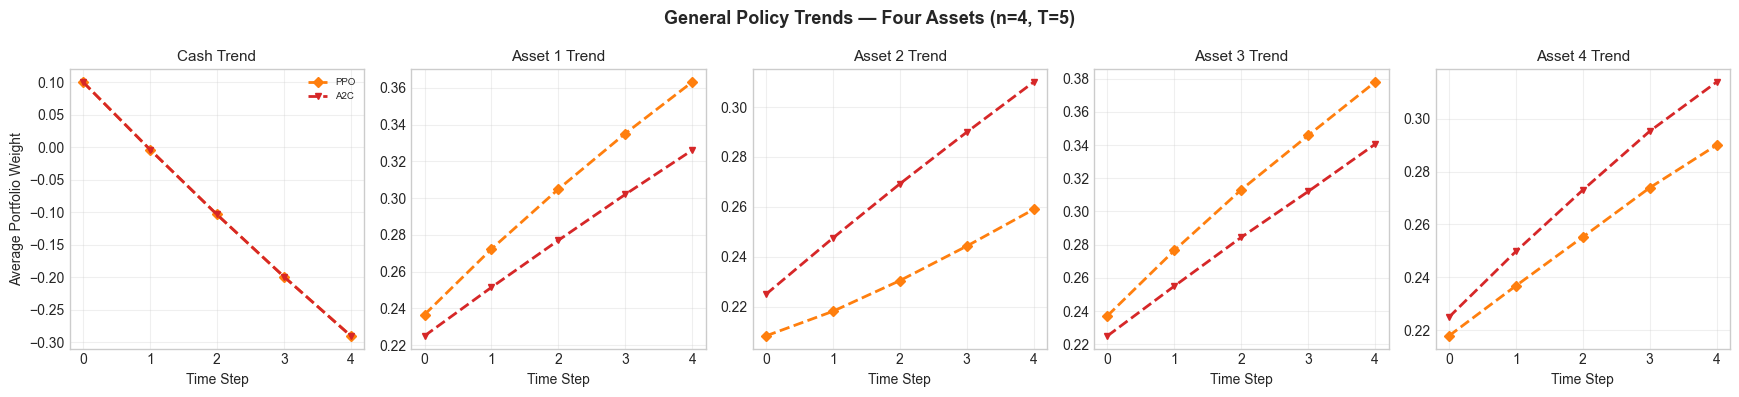

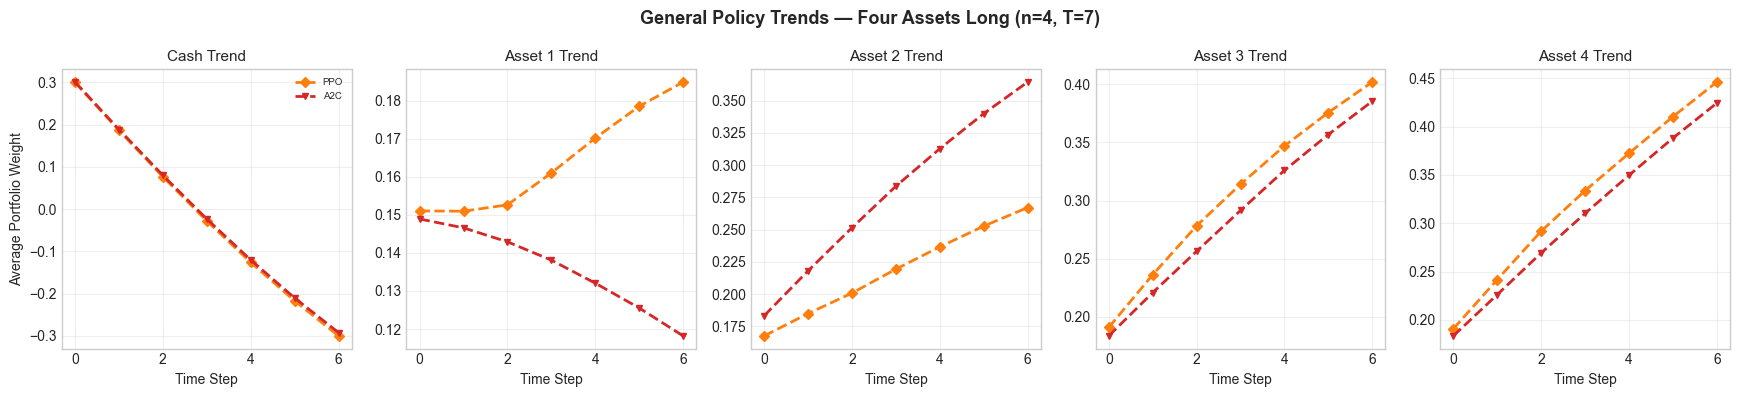

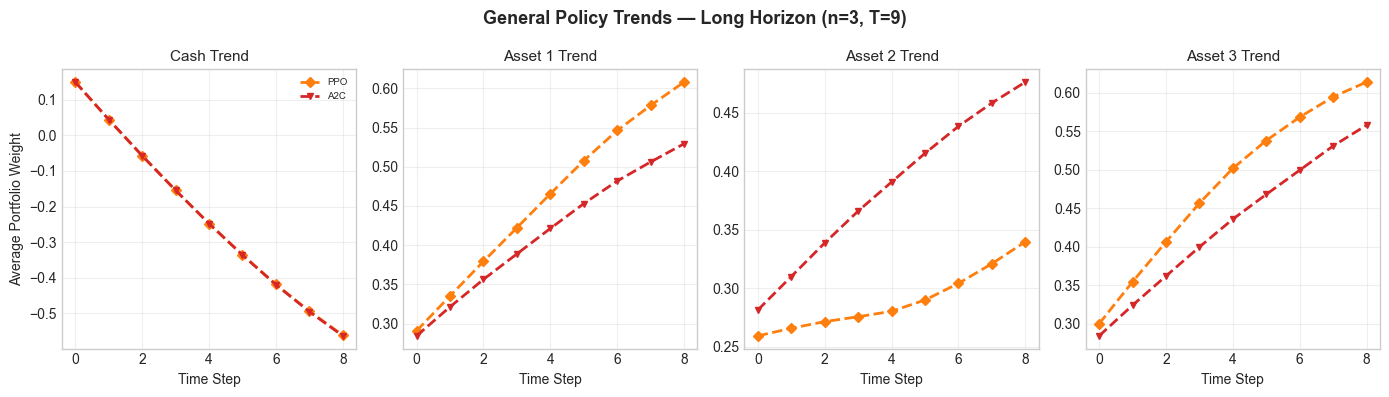

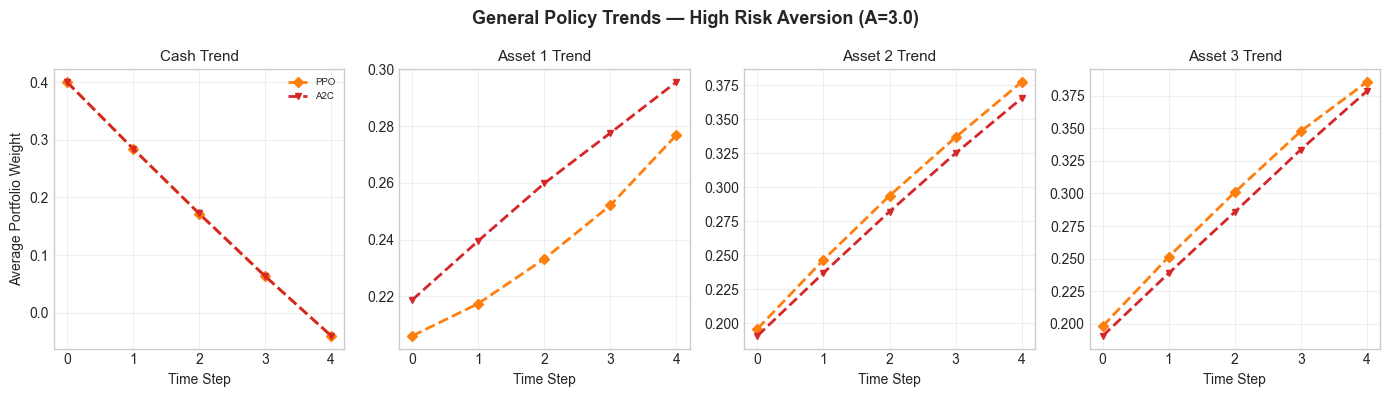

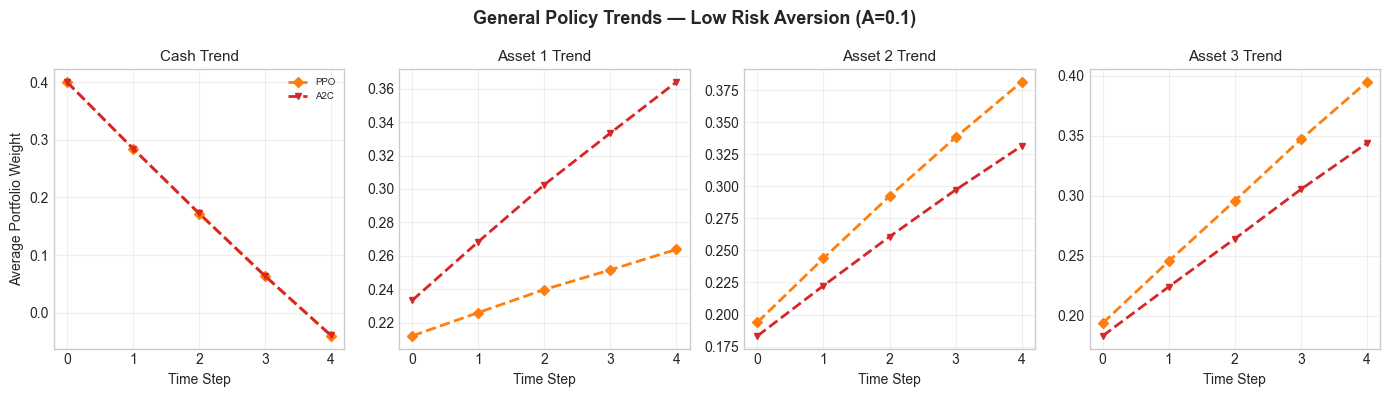

In [22]:
for scenario_name, results in rl_results.items():
    cfg = SCENARIOS[scenario_name]
    n = cfg['n']
    T = cfg['T']
    asset_names = ['Cash'] + [f'Asset {k}' for k in range(1, n + 1)]

    fig, axes = plt.subplots(1, n + 1, figsize=((n + 1) * 3.5, 4))
    if n + 1 == 1:
        axes = [axes]
    time_steps = np.arange(T)

    for asset_idx in range(n + 1):
        ax = axes[asset_idx]
        for method in results:
            alloc = results[method].get('alloc_history')
            if alloc is None or len(alloc.shape) != 3:
                continue
            mean_trend = alloc[:, :, asset_idx].mean(axis=0)
            c = colors.get(method, 'black')
            ls = linestyles.get(method, '--')
            mk = markers.get(method, 'o')
            ax.plot(time_steps, mean_trend, marker=mk, linestyle=ls,
                    label=method, color=c, linewidth=2, markersize=5)
        ax.set_title(f'{asset_names[asset_idx]} Trend', fontsize=11)
        ax.set_xlabel('Time Step')
        ax.grid(True, alpha=0.3)
        if asset_idx == 0:
            ax.set_ylabel('Average Portfolio Weight')
            ax.legend(loc='best', fontsize=7)

    fig.suptitle(f'General Policy Trends — {scenario_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Summary Table

In [23]:
for scenario_name, results in rl_results.items():
    n = SCENARIOS[scenario_name]['n']
    print(f"\n{'='*80}")
    print(f"  {scenario_name}")
    print(f"{'='*80}")
    print(f"  {'Method':<16} {'Avg Utility':>12} {'+/- SE':>10} {'Avg Wealth':>12} {'Med Wealth':>12}")
    print(f"  {'-'*62}")
    for name, res in results.items():
        print(f"  {name:<16} {res['avg_utility']:>12.5f} {res['std_err']:>10.5f} "
              f"{res['avg_wealth']:>12.4f} {res['med_wealth']:>12.4f}")


  Base (n=3, T=5)
  Method            Avg Utility     +/- SE   Avg Wealth   Med Wealth
  --------------------------------------------------------------
  PPO                   1.04637    0.00338       1.5079       1.4749
  A2C                   1.04251    0.00326       1.4977       1.4640

  Two Assets (n=2, T=5)
  Method            Avg Utility     +/- SE   Avg Wealth   Med Wealth
  --------------------------------------------------------------
  PPO                   0.96061    0.00267       1.6454       1.5942
  A2C                   0.95787    0.00263       1.6349       1.5825

  Four Assets (n=4, T=5)
  Method            Avg Utility     +/- SE   Avg Wealth   Med Wealth
  --------------------------------------------------------------
  PPO                   1.04505    0.00301       1.4992       1.4733
  A2C                   1.04151    0.00292       1.4903       1.4681

  Four Assets Long (n=4, T=7)
  Method            Avg Utility     +/- SE   Avg Wealth   Med Wealth
  ------------

## 4. Observations

### Utility and Wealth Convergence

PPO and A2C produce **nearly identical utility and wealth trajectories** across all 7 scenarios, despite using fundamentally different update rules (clipped surrogate vs advantage actor-critic). The utility gap between the two is consistently within 1 standard error, indicating they converge to the same expected outcome.

### Allocation Convergence

The allocation trend plots confirm that both methods learn the **same policy**:
- In the **Base (n=3, T=5)** scenario, both PPO and A2C progressively reduce Cash and increase Asset 3 (highest excess return $\mu_3 - r = 0.07$), with overlapping allocation lines.
- In the **High Risk Aversion (A=3.0)** scenario, both methods adopt a more conservative strategy with smaller risky allocations — the risk aversion parameter correctly modulates the learned policy in the same way for both algorithms.
- At $n = 4$, both methods scale gracefully and still converge, unlike Tabular DP which suffers from the curse of dimensionality (see DP.ipynb).

### PPO vs A2C

PPO slightly outperforms A2C in most scenarios (by 0.1–0.5% in utility), likely due to its clipped surrogate objective providing more stable updates. However, the difference is small and both methods are competitive, confirming that the solution is robust to algorithm choice.

### Model-Free Learning

Both agents learn without any knowledge of the return distribution $\mathcal{N}(\mu_k, \sigma_k^2)$. They discover the optimal rebalancing strategy purely through trial-and-error interaction with the environment — yet arrive at the same policy as the DP methods that exploit full model knowledge (see Compare.ipynb for the cross-method comparison).